In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [2]:
df = pd.read_csv('../data/layoffs.csv')

df.head()

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.20,Unknown
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.30,Unknown
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.10,Unknown
4,Yext,New York City,Marketing,NaN,2024-06-05,https://www.investing.com/news/economy-news/ye...,117.0,Post-IPO,2024-06-05 18:02:40,United States,0.12,Unknown


In [3]:
df.shape

(3642, 12)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3642 entries, 0 to 3641
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Company                     3642 non-null   str    
 1   Location_HQ                 3642 non-null   str    
 2   Industry                    3642 non-null   str    
 3   Laid_Off_Count              2389 non-null   float64
 4   Date                        3642 non-null   str    
 5   Source                      3642 non-null   str    
 6   Funds_Raised                3252 non-null   float64
 7   Stage                       3642 non-null   str    
 8   Date_Added                  3642 non-null   str    
 9   Country                     3642 non-null   str    
 10  Percentage                  2342 non-null   float64
 11  List_of_Employees_Laid_Off  3642 non-null   str    
dtypes: float64(3), str(9)
memory usage: 951.6 KB


In [5]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Company,3642,2596,Google,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Location_HQ,3642,240,SF Bay Area,905,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Industry,3642,31,Finance,451,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Laid_Off_Count,2389.0,NaN,NaN,NaN,257.926329,829.432277,3.0,40.0,80.0,181.0,14000.0
Date,3642,825,2020-04-02,27,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,3642,3407,Internal memo,98,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Funds_Raised,3252.0,NaN,NaN,NaN,798.569494,4758.393161,0.0,51.0,166.0,469.25,121900.0
Stage,3642,16,Post-IPO,768,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date_Added,3642,3603,2020-03-28 20:52:49,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Country,3642,63,United States,2369,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [6]:
df['Date'] = pd.to_datetime(df['Date'])

In [7]:
df = df.dropna(subset=['Laid_Off_Count'])
df['Laid_Off_Count'] = df['Laid_Off_Count'].fillna(0)

In [8]:
df['Company'] = df['Company'].str.strip()
df['Industry'] = df['Industry'].str.strip()
df['Country'] = df['Country'].str.strip()

In [9]:
df = df.drop_duplicates()

In [10]:
df['year'] = df['Date'].dt.year
df['month'] = df['Date'].dt.month
df['quarter'] = df['Date'].dt.quarter

In [11]:
df['Funds_Raised'] = df['Funds_Raised'].fillna(0)

In [12]:
monthly_total = df.groupby(['year','month'])['Laid_Off_Count'].transform('sum')
df['wave_month'] = (monthly_total > 50000).astype(int)

In [13]:
df.info()

<class 'pandas.DataFrame'>
Index: 2389 entries, 0 to 3641
Data columns (total 16 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Company                     2389 non-null   str           
 1   Location_HQ                 2389 non-null   str           
 2   Industry                    2389 non-null   str           
 3   Laid_Off_Count              2389 non-null   float64       
 4   Date                        2389 non-null   datetime64[us]
 5   Source                      2389 non-null   str           
 6   Funds_Raised                2389 non-null   float64       
 7   Stage                       2389 non-null   str           
 8   Date_Added                  2389 non-null   str           
 9   Country                     2389 non-null   str           
 10  Percentage                  1688 non-null   float64       
 11  List_of_Employees_Laid_Off  2389 non-null   str           
 12  year    

In [14]:
df.isnull().sum()

Company                         0
Location_HQ                     0
Industry                        0
Laid_Off_Count                  0
Date                            0
Source                          0
Funds_Raised                    0
Stage                           0
Date_Added                      0
Country                         0
Percentage                    701
List_of_Employees_Laid_Off      0
year                            0
month                           0
quarter                         0
wave_month                      0
dtype: int64

In [15]:
df.head()

,Company,Location_HQ,Industry,Laid_Off_Count,Date,Source,Funds_Raised,Stage,Date_Added,Country,Percentage,List_of_Employees_Laid_Off,year,month,quarter,wave_month
0,Oda,Oslo,Food,150.0,2024-06-05,https://techcrunch.com/2024/06/05/softbank-bac...,691.0,Unknown,2024-06-05 18:01:25,Norway,NaN,Unknown,2024,6,2,0
1,Pagaya,Tel Aviv,Finance,100.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,2000.0,Post-IPO,2024-06-05 23:11:24,Israel,0.2,Unknown,2024,6,2,0
2,Aleph Farms,Tel Aviv,Food,30.0,2024-06-05,https://www.calcalistech.com/ctechnews/article...,119.0,Unknown,2024-06-05 23:13:43,Israel,0.3,Unknown,2024,6,2,0
3,MoonPay,Dover,Crypto,30.0,2024-06-05,https://www.theblock.co/post/298638/moonpay-la...,651.0,Unknown,2024-06-05 23:12:47,United States,0.1,Unknown,2024,6,2,0
5,Microsoft,Seattle,Other,1000.0,2024-06-03,https://www.theverge.com/2024/6/3/24170902/mic...,1.0,Post-IPO,2024-06-03 20:27:12,United States,NaN,Unknown,2024,6,2,0


In [22]:
monthly_layoffs = df.groupby(['year','month'])['Laid_Off_Count'].sum().reset_index()

monthly_layoffs['date'] = pd.to_datetime(
    monthly_layoffs[['year','month']].assign(day=1)
)

monthly_layoffs = monthly_layoffs.sort_values('date')

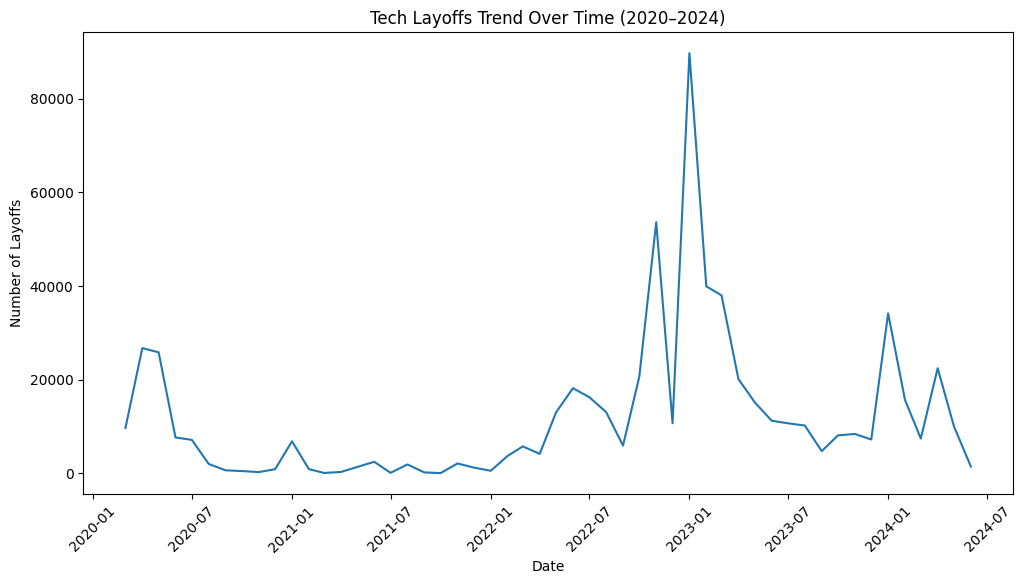

In [23]:
plt.figure(figsize=(12,6))
plt.plot(monthly_layoffs['date'], monthly_layoffs['Laid_Off_Count'])

plt.title("Tech Layoffs Trend Over Time (2020–2024)")
plt.xlabel("Date")
plt.ylabel("Number of Layoffs")
plt.xticks(rotation=45)

plt.show()

In [26]:
peak = monthly_layoffs.loc[monthly_layoffs['Laid_Off_Count'].idxmax()]
peak

year                             2023
month                               1
Laid_Off_Count                89709.0
date              2023-01-01 00:00:00
Name: 33, dtype: object